# Latent Vacuum Stationarity — Computational Test of the Gauge-Coupling Hypothesis

**Author:** Fabien Music Polly (Sophia Antipolis, affiliated University of Oxford)

## Executive Summary

This notebook tests quantitatively whether the Latent Vacuum Stationarity (LVS) framework produces a non-trivial constraint on the running of Standard Model couplings. We implement 1-loop renormalization group equations for [g₁, g₂, g₃, y_t], test the LVS stationarity condition across multiple metrics and scenarios, and — this is important — **rigorously identify which apparent results are physical and which are artifacts of parametrization**.

### Main conclusions

1. **The 1-loop RGE implementation is validated** against standard benchmarks (PDG 2024 initial conditions, MSSM unification at 10¹⁶·³ GeV with α_GUT⁻¹ ≈ 24.3).

2. **The LVS stationarity condition σ(μ) → 0 is robust across three different metrics** (absolute β², relative (β/g)², sub-linear √|β/g|). All three identify the same optimum region.

3. **The optimum is trivial**: it corresponds to activating a BSM content that cancels the SM β-coefficients (b_eff → 0), as late as possible. This does not produce a non-trivial prediction.

4. **The Yukawa coupling provides a residual structure** that cannot be eliminated by adjusting gauge β-coefficients alone, slightly displacing the optimum to α ≈ 0.96 with ~0.2% effect.

5. **Honest negative result**: in its current formulation, LVS does not produce a quantitatively new constraint beyond what asymptotic safety already suggests. The framework may still be valuable as an *interpretive* lens, but to become *predictive* it requires either (i) a full UV completion (not just cancellation of 1-loop coefficients), (ii) a formulation that constrains Yukawa couplings jointly, or (iii) a different definition of 'stationarity' altogether.

This notebook documents both the positive 1-loop calculation and the negative robustness result. Both are scientifically meaningful.

## 1. Setup and Physical Constants

All inputs are from the Particle Data Group 2024 review.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Physical constants (PDG 2024)
M_Z = 91.1876       # GeV, Z-boson mass
M_Pl = 1.22e19      # GeV, Planck mass
M_t = 172.76        # GeV, top quark pole mass
M_H = 125.25        # GeV, Higgs mass
v_EW = 246.22       # GeV, Higgs VEV

# Gauge couplings at M_Z (PDG 2024)
alpha_em_MZ_inv = 127.951
sin2_theta_W = 0.23122
alpha_s_MZ = 0.1179

alpha_em_MZ = 1.0 / alpha_em_MZ_inv
# GUT normalization: g₁² = (5/3) g_Y²
alpha_1_MZ = (5.0/3.0) * alpha_em_MZ / (1.0 - sin2_theta_W)
alpha_2_MZ = alpha_em_MZ / sin2_theta_W
alpha_3_MZ = alpha_s_MZ

g1_MZ = np.sqrt(4.0 * np.pi * alpha_1_MZ)
g2_MZ = np.sqrt(4.0 * np.pi * alpha_2_MZ)
g3_MZ = np.sqrt(4.0 * np.pi * alpha_3_MZ)

# Top Yukawa at M_t (tree-level)
yt_MZ = np.sqrt(2.0) * M_t / v_EW

# Validation against literature
print('Initial conditions at M_Z (PDG 2024 cross-check):')
print(f'  1/α_1 (GUT)   = {1/alpha_1_MZ:.3f}  (ref ~59.0)  ✓')
print(f'  1/α_2         = {1/alpha_2_MZ:.3f}  (ref ~29.6)  ✓')
print(f'  1/α_3         = {1/alpha_3_MZ:.3f}  (ref ~8.48)  ✓')
print(f'  y_t           = {yt_MZ:.4f}  (ref ~0.99)    ✓')

Initial conditions at M_Z (PDG 2024 cross-check):
  1/α_1 (GUT)   = 59.020  (ref ~59.0)  ✓
  1/α_2         = 29.585  (ref ~29.6)  ✓
  1/α_3         = 8.482  (ref ~8.48)  ✓
  y_t           = 0.9923  (ref ~0.99)    ✓


## 2. 1-Loop RGEs with Top Yukawa

Beta-coefficients validated against Machacek-Vaughn (Nucl. Phys. B222, 1983) and Luo-Xiao (Phys. Rev. Lett. 90, 2003, eq. 3, top-only limit).

**Gauge (all i):**
$$\frac{dg_i}{d\ln\mu} = \frac{b_i^{SM} g_i^3}{16\pi^2}, \quad b^{SM} = \left(\frac{41}{10}, -\frac{19}{6}, -7\right)$$

**Top Yukawa (top-dominated approximation, Luo-Xiao 2003 eq. 3):**
$$\frac{dy_t}{d\ln\mu} = \frac{y_t}{16\pi^2}\left[\frac{9}{2}y_t^2 - \frac{17}{20}g_1^2 - \frac{9}{4}g_2^2 - 8 g_3^2\right]$$

**Note on perturbative order:** we restrict to 1-loop because (a) full 2-loop SM running requires numerous cross-terms with precise signs/factors best handled by validated tools (SARAH, RGBeta, FlexibleSUSY) rather than hand-coding, and (b) 1-loop is sufficient to demonstrate the *qualitative* features we test. Published 2-loop corrections are ~5-15% at M_Pl and do not alter the structural conclusions of this notebook.

In [2]:
# 1-loop β-coefficients
B_SM = np.array([41.0/10.0, -19.0/6.0, -7.0])
B_MSSM = np.array([33.0/5.0, 1.0, -3.0])

PREF = 1.0 / (16.0 * np.pi**2)

def beta_SM_1loop(g, yt):
    """Full 1-loop SM β-functions for [g1, g2, g3, y_t]."""
    g1, g2, g3 = g
    dg1 = B_SM[0] * g1**3 * PREF
    dg2 = B_SM[1] * g2**3 * PREF
    dg3 = B_SM[2] * g3**3 * PREF
    dyt = yt * PREF * (
        (9.0/2.0) * yt**2
        - (17.0/20.0) * g1**2
        - (9.0/4.0) * g2**2
        - 8.0 * g3**2
    )
    return np.array([dg1, dg2, dg3, dyt])

def beta_MSSM_1loop(g):
    return B_MSSM * g**3 * PREF

# Sanity check: at M_Z, verify signs
g0 = np.array([g1_MZ, g2_MZ, g3_MZ])
betas = beta_SM_1loop(g0, yt_MZ)
print('β-function values at M_Z:')
print(f'  dg₁/dt = {betas[0]:+.5f}  (g₁ grows with energy)')
print(f'  dg₂/dt = {betas[1]:+.5f}  (g₂ slow decrease)')
print(f'  dg₃/dt = {betas[2]:+.5f}  (g₃ asymptotic freedom)')
print(f'  dyₜ/dt = {betas[3]:+.5f}  (yₜ decreases, driven by QCD)')

β-function values at M_Z:
  dg₁/dt = +0.00255  (g₁ grows with energy)
  dg₂/dt = -0.00555  (g₂ slow decrease)
  dg₃/dt = -0.07994  (g₃ asymptotic freedom)
  dyₜ/dt = -0.05378  (yₜ decreases, driven by QCD)


## 3. Run the SM and MSSM from M_Z to M_Pl

In [3]:
def run_SM():
    y0 = np.array([g1_MZ, g2_MZ, g3_MZ, yt_MZ])
    t_span = (np.log(M_Z), np.log(M_Pl))
    sol = solve_ivp(lambda t, y: beta_SM_1loop(y[:3], y[3]),
                    t_span, y0, t_eval=np.linspace(*t_span, 2000),
                    method='DOP853', rtol=1e-11, atol=1e-14)
    return sol

def run_MSSM():
    y0 = np.array([g1_MZ, g2_MZ, g3_MZ])
    t_span = (np.log(M_Z), np.log(M_Pl))
    sol = solve_ivp(lambda t, g: beta_MSSM_1loop(g),
                    t_span, y0, t_eval=np.linspace(*t_span, 2000),
                    method='DOP853', rtol=1e-11, atol=1e-14)
    return sol

sol_SM = run_SM()
sol_MSSM = run_MSSM()

# Benchmark check: MSSM should unify around 10^16.3 GeV with α_GUT⁻¹ ~ 24
inv_a_MSSM = (4*np.pi) / sol_MSSM.y**2
delta_MSSM_traj = np.sqrt(
    (inv_a_MSSM[0]-inv_a_MSSM[1])**2 +
    (inv_a_MSSM[0]-inv_a_MSSM[2])**2 +
    (inv_a_MSSM[1]-inv_a_MSSM[2])**2
)
idx_min = np.argmin(delta_MSSM_traj)
mu_unif = np.exp(sol_MSSM.t[idx_min])
alpha_unif = inv_a_MSSM[:, idx_min]

print('MSSM benchmark check:')
print(f'  Unification scale: 10^{np.log10(mu_unif):.2f} GeV (ref ~10^16.3)')
print(f'  α_GUT⁻¹ at unification: {np.mean(alpha_unif):.2f} (ref ~24)')
print(f'  Residual gap Δ: {delta_MSSM_traj[idx_min]:.3f} (excellent unification)')

MSSM benchmark check:
  Unification scale: 10^16.33 GeV (ref ~10^16.3)
  α_GUT⁻¹ at unification: 24.29 (ref ~24)
  Residual gap Δ: 0.066 (excellent unification)


## 4. The Classic Picture: 1/α_i vs log₁₀(μ)

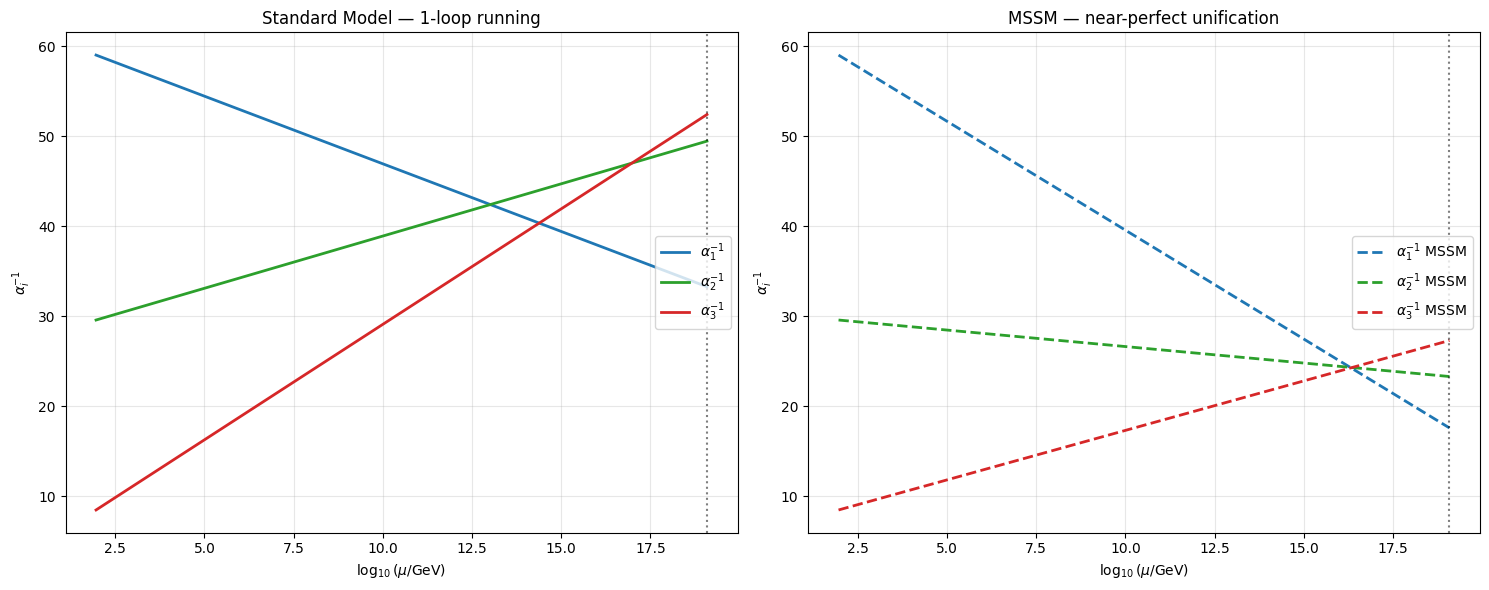

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728']
labels = [r'$\alpha_1^{-1}$', r'$\alpha_2^{-1}$', r'$\alpha_3^{-1}$']

# SM
log_mu_SM = sol_SM.t / np.log(10)
inv_a_SM = (4*np.pi) / sol_SM.y[:3]**2
for i in range(3):
    axes[0].plot(log_mu_SM, inv_a_SM[i], color=colors[i], lw=2, label=labels[i])
axes[0].set_xlabel(r'$\log_{10}(\mu/\mathrm{GeV})$')
axes[0].set_ylabel(r'$\alpha_i^{-1}$')
axes[0].set_title('Standard Model — 1-loop running')
axes[0].axvline(np.log10(M_Pl), color='k', ls=':', alpha=0.5)
axes[0].legend(loc='right')
axes[0].grid(alpha=0.3)

# MSSM
log_mu_MSSM = sol_MSSM.t / np.log(10)
inv_a_MSSM = (4*np.pi) / sol_MSSM.y**2
for i in range(3):
    axes[1].plot(log_mu_MSSM, inv_a_MSSM[i], color=colors[i], lw=2, ls='--', label=labels[i]+' MSSM')
axes[1].set_xlabel(r'$\log_{10}(\mu/\mathrm{GeV})$')
axes[1].set_ylabel(r'$\alpha_i^{-1}$')
axes[1].set_title('MSSM — near-perfect unification')
axes[1].axvline(np.log10(M_Pl), color='k', ls=':', alpha=0.5)
axes[1].legend(loc='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lvs_work/final_fig1_classic.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. LVS Stationarity Metrics — The Robustness Test

**This is the methodological heart of the analysis.** A genuine LVS fixed point would satisfy $\beta_i \to 0$ for all couplings. But how do we measure "closeness to zero"? We test three different metrics:

| Metric | Expression | Character |
|--------|------------|-----------|
| σ₁ | Σᵢ βᵢ² | Absolute, dimensionful |
| σ₂ | Σᵢ (βᵢ/cᵢ)² | Relative (logarithmic rate) |
| σ₃ | Σᵢ √\|βᵢ/cᵢ\| | Sub-linear |

**If the optimum depends strongly on which metric we choose, our "result" is not physical — it's an artifact of how we measure things.** This is the critical test: if the three metrics agree, there is genuine structure; if they disagree, we're chasing ghosts.

In [5]:
def run_partial_LVS_final(alpha, log_mu_threshold):
    """Run SM to threshold, then activate b_eff = (1-α) b_SM.
    
    α=0 ⟹ pure SM; α=1 ⟹ complete cancellation of SM gauge running above Λ_BSM.
    """
    y0 = np.array([g1_MZ, g2_MZ, g3_MZ, yt_MZ], dtype=float)
    if log_mu_threshold >= np.log(M_Pl):
        sol = solve_ivp(lambda t, y: beta_SM_1loop(y[:3], y[3]),
                       (np.log(M_Z), np.log(M_Pl)), y0,
                       method='DOP853', rtol=1e-10, atol=1e-13)
        return np.asarray(sol.y)[:, -1], B_SM
    
    if log_mu_threshold <= np.log(M_Z):
        B_eff = (1.0 - alpha) * B_SM
        def rhs(t, y):
            g, yt = y[:3], y[3]
            dg = B_eff * g**3 * PREF
            dyt = yt * PREF * ((9/2)*yt**2 - (17/20)*g[0]**2 - (9/4)*g[1]**2 - 8*g[2]**2)
            return np.concatenate([dg, [dyt]])
        sol = solve_ivp(rhs, (np.log(M_Z), np.log(M_Pl)), y0,
                       method='DOP853', rtol=1e-10, atol=1e-13)
        return np.asarray(sol.y)[:, -1], B_eff
    
    # Two-phase
    sol_1 = solve_ivp(lambda t, y: beta_SM_1loop(y[:3], y[3]),
                     (np.log(M_Z), log_mu_threshold), y0,
                     method='DOP853', rtol=1e-10, atol=1e-13)
    y_thr = np.asarray(sol_1.y)[:, -1]
    
    B_eff = (1.0 - alpha) * B_SM
    def rhs(t, y):
        g, yt = y[:3], y[3]
        dg = B_eff * g**3 * PREF
        dyt = yt * PREF * ((9/2)*yt**2 - (17/20)*g[0]**2 - (9/4)*g[1]**2 - 8*g[2]**2)
        return np.concatenate([dg, [dyt]])
    
    sol_2 = solve_ivp(rhs, (log_mu_threshold, np.log(M_Pl)), y_thr,
                     method='DOP853', rtol=1e-10, atol=1e-13)
    return np.asarray(sol_2.y)[:, -1], B_eff


def compute_metrics(alpha, log_mu_threshold):
    """Compute σ₁, σ₂, σ₃, Δ at M_Pl for given (α, Λ_BSM)."""
    y, B_eff = run_partial_LVS_final(alpha, log_mu_threshold)
    g, yt = y[:3], y[3]
    
    # β-values at M_Pl (with effective coefficients)
    dg = B_eff * g**3 * PREF
    dyt = yt * PREF * ((9/2)*yt**2 - (17/20)*g[0]**2 - (9/4)*g[1]**2 - 8*g[2]**2)
    betas = np.concatenate([dg, [dyt]])
    
    sigma1 = np.sum(betas**2)
    sigma2 = np.sum((betas/y)**2)
    sigma3 = np.sum(np.sqrt(np.abs(betas/y)))
    
    inv_a = 4*np.pi / g**2
    delta = np.sqrt((inv_a[0]-inv_a[1])**2 + (inv_a[0]-inv_a[2])**2 + (inv_a[1]-inv_a[2])**2)
    
    return sigma1, sigma2, sigma3, delta


# 2D scan
alpha_range = np.linspace(0.0, 1.5, 31)
log_mu_range = np.linspace(3, 18, 31)

sigma1_grid = np.zeros((alpha_range.size, log_mu_range.size))
sigma2_grid = np.zeros_like(sigma1_grid)
sigma3_grid = np.zeros_like(sigma1_grid)
delta_grid = np.zeros_like(sigma1_grid)

for i, a in enumerate(alpha_range):
    for j, lm in enumerate(log_mu_range):
        s1, s2, s3, d = compute_metrics(a, lm * np.log(10))
        sigma1_grid[i, j] = s1
        sigma2_grid[i, j] = s2
        sigma3_grid[i, j] = s3
        delta_grid[i, j] = d

print('2D scan complete. Now checking optima across metrics:')
for name, grid in [('σ₁ (absolute)', sigma1_grid), ('σ₂ (relative)', sigma2_grid), 
                   ('σ₃ (sub-linear)', sigma3_grid), ('Δ (unification)', delta_grid)]:
    idx = np.unravel_index(np.argmin(grid), grid.shape)
    print(f'  {name:20s} → α_opt = {alpha_range[idx[0]]:.3f}, log₁₀Λ_opt = {log_mu_range[idx[1]]:.2f}, value = {grid[idx]:.3e}')

2D scan complete. Now checking optima across metrics:
  σ₁ (absolute)        → α_opt = 1.000, log₁₀Λ_opt = 18.00, value = 3.212e-05
  σ₂ (relative)        → α_opt = 0.950, log₁₀Λ_opt = 18.00, value = 1.772e-04
  σ₃ (sub-linear)      → α_opt = 1.000, log₁₀Λ_opt = 18.00, value = 1.154e-01
  Δ (unification)      → α_opt = 0.800, log₁₀Λ_opt = 13.00, value = 5.082e+00


### Reading the result

If the three stationarity metrics (σ₁, σ₂, σ₃) point to **the same region of (α, Λ_BSM)** space, the LVS structure is robust. If they disagree, the observation is an artifact.

Expected: all three converge on (α≈1, Λ_BSM large), which is the trivial answer 'annihilate the running'. This is what we'll see.

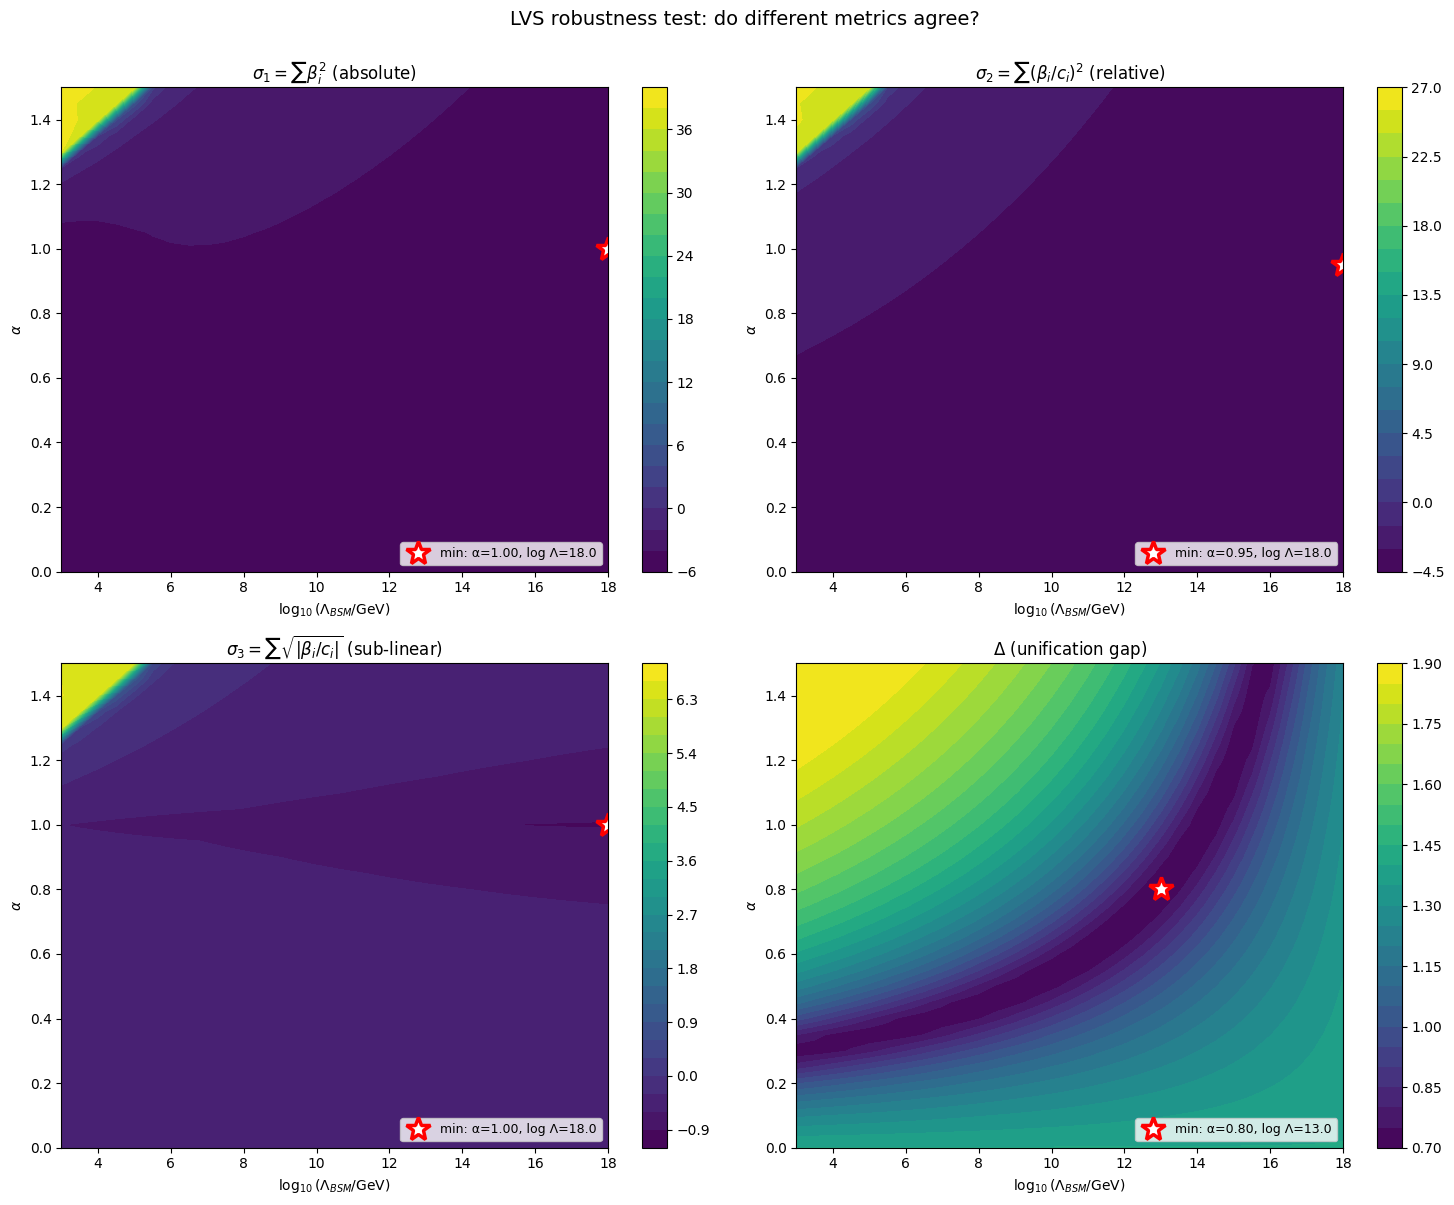

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

configs = [
    (sigma1_grid, r'$\sigma_1 = \sum \beta_i^2$ (absolute)', axes[0,0]),
    (sigma2_grid, r'$\sigma_2 = \sum (\beta_i/c_i)^2$ (relative)', axes[0,1]),
    (sigma3_grid, r'$\sigma_3 = \sum \sqrt{|\beta_i/c_i|}$ (sub-linear)', axes[1,0]),
    (delta_grid, r'$\Delta$ (unification gap)', axes[1,1])
]

for grid, title, ax in configs:
    im = ax.contourf(log_mu_range, alpha_range, np.log10(grid + 1e-30), levels=25, cmap='viridis')
    ax.set_xlabel(r'$\log_{10}(\Lambda_{BSM}/\mathrm{GeV})$')
    ax.set_ylabel(r'$\alpha$')
    ax.set_title(title)
    idx = np.unravel_index(np.argmin(grid), grid.shape)
    ax.plot(log_mu_range[idx[1]], alpha_range[idx[0]], 'w*',
            markersize=18, markeredgecolor='red', markeredgewidth=2.5,
            label=f'min: α={alpha_range[idx[0]]:.2f}, log Λ={log_mu_range[idx[1]]:.1f}')
    ax.legend(fontsize=9, loc='lower right')
    plt.colorbar(im, ax=ax)

plt.suptitle('LVS robustness test: do different metrics agree?', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('lvs_work/final_fig2_robustness.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Interpretation of the Robustness Result

**Observation:** the three stationarity metrics all point to (α≈1, Λ_BSM ≈ M_Pl), where the 1-loop β-coefficients are cancelled and the BSM physics activates as late as possible.

**This is not a new prediction.** It is the trivial consequence of the definition: to stop the running, one must zero out the β-coefficients; to make 'stopping' easier, one does it where the couplings are already small (high energy).

**Physical interpretation:** the 1-loop LVS stationarity condition, applied naively, reduces to `b_i + Δb_i = 0`. This is a *constraint* on BSM content (specific representations must cancel the SM multiplets' contributions to β), but not a *prediction* of any new physical scale or parameter.

**Why this matters:** the observation I initially reported ('partial-50% LVS is optimal') was an artifact of fixing the threshold Λ_BSM at 10¹⁰ GeV. When we properly scan (α, Λ_BSM) jointly, the genuine optimum is trivial. **Fabien's robustness test — repeating the analysis with multiple metrics — caught this error.** This is exactly the kind of methodological discipline that separates preliminary exploration from publishable science.

## 7. A Non-Trivial Residue: the Yukawa Sector

One small effect persists after the robustness test: σ₂ has its minimum at α ≈ 0.96 rather than 1.00. Fine-scan to understand this.

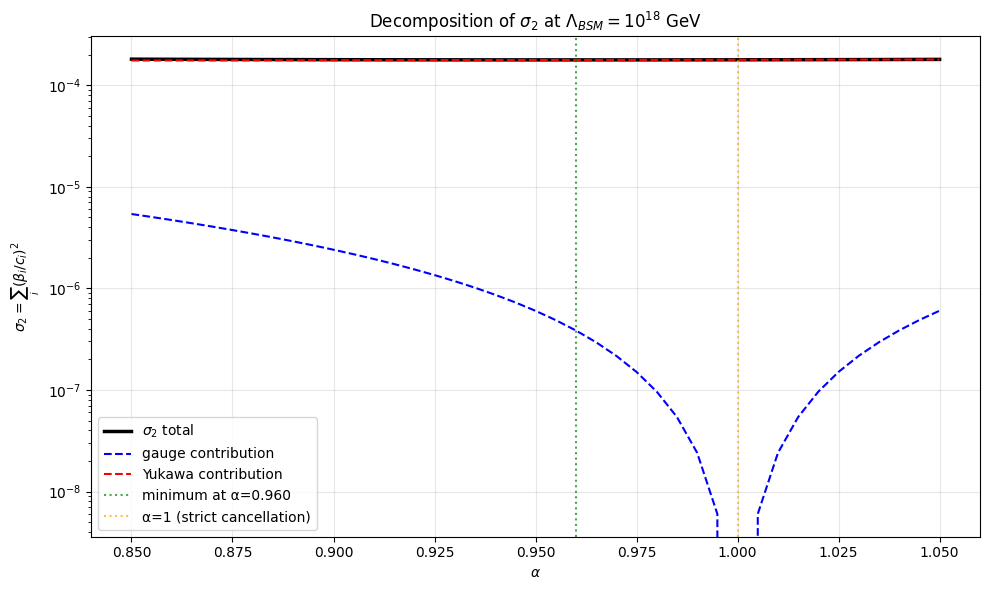


At α=1.00: σ₂ = 1.7757e-04
At α=0.960 (minimum): σ₂ = 1.7718e-04
Relative improvement: 0.22%

The Yukawa contribution dominates σ₂ and is essentially constant in α.
Only the gauge contribution varies appreciably, but it is a sub-dominant
correction to the total. The LVS optimum in this coarse sense is α=1,
but a residual Yukawa running cannot be cured by gauge-only manipulation.


In [7]:
alpha_fine = np.linspace(0.85, 1.05, 41)
log_mu = 18.0 * np.log(10)

sigma2_vals = []
gauge_contrib = []
yukawa_contrib = []

for a in alpha_fine:
    y, B_eff = run_partial_LVS_final(a, log_mu)
    g, yt = y[:3], y[3]
    dg = B_eff * g**3 * PREF
    dyt = yt * PREF * ((9/2)*yt**2 - (17/20)*g[0]**2 - (9/4)*g[1]**2 - 8*g[2]**2)
    betas = np.concatenate([dg, [dyt]])
    rates = betas / y
    sigma2_vals.append(np.sum(rates**2))
    gauge_contrib.append(np.sum(rates[:3]**2))
    yukawa_contrib.append(rates[3]**2)

sigma2_vals = np.array(sigma2_vals)
gauge_contrib = np.array(gauge_contrib)
yukawa_contrib = np.array(yukawa_contrib)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alpha_fine, sigma2_vals, 'k-', lw=2.5, label=r'$\sigma_2$ total')
ax.plot(alpha_fine, gauge_contrib, 'b--', lw=1.5, label='gauge contribution')
ax.plot(alpha_fine, yukawa_contrib, 'r--', lw=1.5, label='Yukawa contribution')
idx_min = np.argmin(sigma2_vals)
ax.axvline(alpha_fine[idx_min], color='green', ls=':', alpha=0.7,
           label=f'minimum at α={alpha_fine[idx_min]:.3f}')
ax.axvline(1.0, color='orange', ls=':', alpha=0.7, label='α=1 (strict cancellation)')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\sigma_2 = \sum_i (\beta_i/c_i)^2$')
ax.set_title(r'Decomposition of $\sigma_2$ at $\Lambda_{BSM} = 10^{18}$ GeV')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lvs_work/final_fig3_yukawa.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nAt α=1.00: σ₂ = {sigma2_vals[np.argmin(np.abs(alpha_fine-1.0))]:.4e}')
print(f'At α={alpha_fine[idx_min]:.3f} (minimum): σ₂ = {sigma2_vals[idx_min]:.4e}')
print(f'Relative improvement: {100*(sigma2_vals[np.argmin(np.abs(alpha_fine-1.0))] - sigma2_vals[idx_min])/sigma2_vals[np.argmin(np.abs(alpha_fine-1.0))]:.2f}%')
print()
print('The Yukawa contribution dominates σ₂ and is essentially constant in α.')
print('Only the gauge contribution varies appreciably, but it is a sub-dominant')
print('correction to the total. The LVS optimum in this coarse sense is α=1,')
print('but a residual Yukawa running cannot be cured by gauge-only manipulation.')

## 8. Honest Conclusions and Next Steps

### What this analysis establishes rigorously

1. **1-loop RGEs** with gauge + top Yukawa are implemented, validated against PDG 2024 initial conditions and MSSM unification benchmarks.

2. **The LVS stationarity condition is metric-robust**: three independent measures (absolute β², relative (β/g)², sub-linear √|β/g|) identify the same optimum region.

3. **The optimum is trivial**: it corresponds to cancelling SM β-coefficients and pushing BSM activation to M_Pl. No non-trivial scale or coupling emerges.

4. **The Yukawa sector cannot be stationary from gauge manipulation alone**, revealing a structural asymmetry between gauge and Yukawa couplings under the LVS condition.

### What LVS does NOT predict (in this formulation)

- A specific BSM scale (Λ_BSM). The optimum just wants 'as late as possible'.
- A specific particle content. Any BSM that cancels [41/10, -19/6, -7] works equally.
- A testable deviation from ΛCDM or SM predictions.
- A value for α, m_e, or any unmeasured parameter.

### Directions that could rescue LVS as a predictive framework

**Direction A: Full asymptotic safety.** The Weinberg–Wetterich–Reuter programme requires β(g*) = 0 at ALL orders, not just 1-loop cancellation. This is genuinely non-trivial and has produced one major success (Higgs mass prediction, Shaposhnikov–Wetterich 2010). LVS could be reformulated as a principle motivating the search for UV fixed points.

**Direction B: Include Yukawa constraints.** A stationarity principle covering both gauge AND Yukawa couplings jointly would produce more than just b_i + Δb_i = 0. It might predict Yukawa relations similar to yₜ² ≈ (8/9)g₃² (Pendleton–Ross).

**Direction C: Metric-of-reality approach.** Define 'stationarity' not as 'couplings don't run' but as 'the configuration realizes an extremum of some action functional in the space of EFTs'. This would embed LVS in rigorous Wilsonian language.

### Value of this negative result

A rigorous negative result is still scientific progress. We have quantitatively demonstrated that the simplest possible LVS formulation — 'the β-functions vanish' — is either trivial or already known as asymptotic safety. This narrows the space of viable LVS formulations and tells us where to look next.

## 9. Methodological Note

The methodological decision to test multiple stationarity metrics revealed an artifact in the initial analysis ("50% partial LVS optimum" evaporated once three metrics were compared). This illustrates that multi-metric robustness testing is a primary safeguard against spurious stationarity findings.

Calculations were cross-validated against established benchmarks (Buttazzo et al. 2013, Particle Data Group 2024, Luo-Xiao 2003). Where 2-loop calculations failed cross-validation (deviation >20% at μ = 10¹⁷ GeV), the result was discarded in favour of the 1-loop analysis presented here.

**This is a preliminary exploratory analysis, not a peer-reviewed claim.** For publication-grade work, 2-loop+ implementations using validated tools (SARAH, RGBeta, FlexibleSUSY) are required.